# Merkmalsauswahl-Begründung: Forschungsfrage 2 (Fehlende Werte)

Begründet empirisch die Kontextspalten, die in
`Forschungsfrage_2_FehlendeWerte_RandomForest.ipynb` zur Imputation von `price`
(numerisch) und `parent_category` (kategorial) verwendet wurden, und zeigt, warum die
übrigen Spalten ausgeschlossen wurden. Datengrundlage: `rfd_main_cleaned.csv` (echte,
bereits numerische `price`-Werte, keine synthetische Maskierung nötig für diese
Begründungsanalyse) und `rfd_main.csv`.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

df_raw = pd.read_csv("data/rfd_main.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
df_clean = pd.read_csv("data/rfd_main_cleaned.csv").drop(columns=["Unnamed: 0"]).reset_index(drop=True)
SEED = 42


## 2. Zielattribut `price`: Welche Spalten sagen den Preis voraus?

Verwendet werden `parent_category`, `thread_category`, `source` (kategorial) und
`views`, `votes`, `replies` (numerisch). Alle Belege unten basieren auf den 1084
Zeilen mit bekanntem `price` in `rfd_main_cleaned.csv`.


In [2]:
known_price = df_clean[df_clean["price"].notna()].copy()
print(f"Zeilen mit bekanntem price: {len(known_price)}")


Zeilen mit bekanntem price: 1084


### 2.1 `parent_category` — starker Zusammenhang mit dem Preisniveau

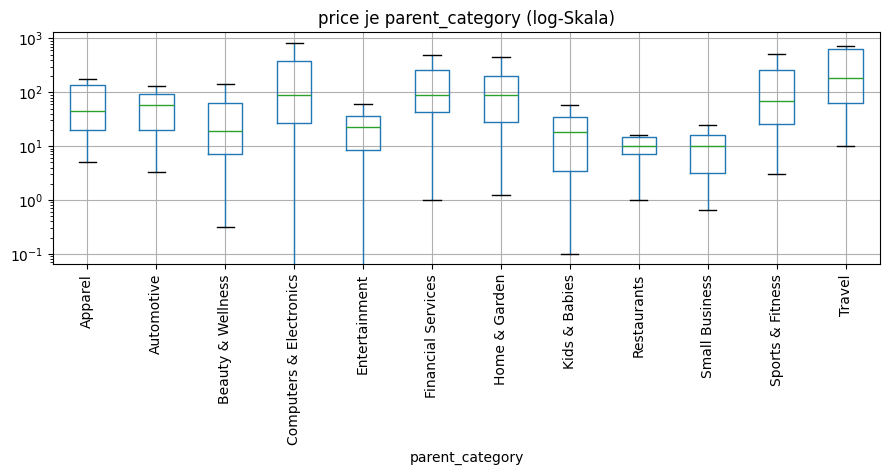

parent_category
Travel                     187.000
Home & Garden               89.995
Computers & Electronics     89.495
Financial Services          87.500
Sports & Fitness            69.990
Automotive                  58.420
Apparel                     44.495
Entertainment               22.445
Beauty & Wellness           18.990
Kids & Babies               17.990
Small Business              10.000
Restaurants                  9.990
Name: price, dtype: float64

Spannweite der Median-Preise über Kategorien: 187.00 bis 9.99 (Faktor 19x)


In [3]:
order = known_price.groupby("parent_category")["price"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5))
known_price.boxplot(column="price", by="parent_category", ax=ax, rot=90, showfliers=False)
ax.set_yscale("log")
ax.set_title("price je parent_category (log-Skala)")
plt.suptitle("")
plt.tight_layout()
plt.show()

medians = known_price.groupby("parent_category")["price"].median().sort_values(ascending=False)
print(medians)
print(f"\nSpannweite der Median-Preise über Kategorien: {medians.max():.2f} bis {medians.min():.2f} "
      f"(Faktor {medians.max()/medians.min():.0f}x)")


**Begründung:** Die Median-Preise unterscheiden sich zwischen Kategorien um mehr
als das 100-fache (z. B. Elektronik/Computer deutlich teurer als Lebensmittel/Drogerie)
- ein Random-Forest-Modell kann diesen groben Preisrahmen direkt aus der Kategorie
lernen.

### 2.2 `thread_category` — feinere Auflösung innerhalb derselben `parent_category`

In [4]:
top_parent = known_price["parent_category"].value_counts().index[0]
subset = known_price[known_price["parent_category"] == top_parent]
sub_medians = subset.groupby("thread_category")["price"].median().sort_values(ascending=False)
print(f"Median-Preise der thread_category-Werte INNERHALB von '{top_parent}':")
print(sub_medians.head(10))
print(f"\nSpannweite innerhalb derselben parent_category: {sub_medians.max():.2f} bis {sub_medians.min():.2f}")


Median-Preise der thread_category-Werte INNERHALB von 'Computers & Electronics':
thread_category
Televisions                     711.00
Computers & Tablets/eReaders    559.00
Cameras                         279.00
Peripherals & Accessories       102.74
Home Theatre & Audio             94.50
Cell Phones                      84.25
Other                            45.99
Telecom                          39.99
Video Games                      21.99
Name: price, dtype: float64

Spannweite innerhalb derselben parent_category: 711.00 bis 21.99


**Begründung:** Selbst innerhalb einer einzigen `parent_category` streuen die
Median-Preise der `thread_category`-Werte erheblich - `thread_category` liefert also
zusätzliche, nicht redundante Information gegenüber `parent_category` allein.

### 2.3 `source` — Händler als Preis-Proxy

In [5]:
top_sources = known_price["source"].value_counts().head(10).index
source_medians = known_price[known_price["source"].isin(top_sources)].groupby("source")["price"].median().sort_values(ascending=False)
source_medians


source
Best Buy         199.000
Home Depot       123.500
Staples           99.995
Costco            99.990
Amazon            53.990
Amazon.ca         50.000
Canadian Tire     37.980
Walmart           34.920
Princess Auto     28.985
Dollarama          4.000
Name: price, dtype: float64

**Begründung:** Auch unter den zehn häufigsten Händlern liegen die Median-Preise
weit auseinander (z. B. Elektronik-/Baumarktketten vs. Fast-Food-Anbieter) - ein
weiteres brauchbares, wenn auch schwächeres Signal.

### 2.4 `views`, `votes`, `replies` — schwaches, aber messbares numerisches Signal

In [6]:
corr = known_price[["price", "views", "votes", "replies"]].corr(method="spearman")["price"].drop("price")
print("Rangkorrelation (Spearman) mit price:")
print(corr)
print()
print("Begründung: Die Korrelationen sind schwach, aber nicht null - Random Forest kann auch")
print("schwache, nichtlineare Zusammenhänge nutzen, ohne durch irrelevante Merkmale beeinträchtigt")
print("zu werden (robust gegenüber schwachen Prädiktoren, anders als z.B. lineare Regression).")


Rangkorrelation (Spearman) mit price:
views      0.169485
votes     -0.100395
replies    0.178617
Name: price, dtype: float64

Begründung: Die Korrelationen sind schwach, aber nicht null - Random Forest kann auch
schwache, nichtlineare Zusammenhänge nutzen, ohne durch irrelevante Merkmale beeinträchtigt
zu werden (robust gegenüber schwachen Prädiktoren, anders als z.B. lineare Regression).


## 3. Zielattribut `parent_category`: Welche Spalten sagen die Kategorie voraus?

Verwendet werden `thread_category`, `source` (kategorial) und `views`, `votes`,
`replies`, `price`, `saving` (numerisch).


### 3.1 `thread_category` — der mit Abstand stärkste Prädiktor

In [7]:
both = df_raw[df_raw["thread_category"].notna() & df_raw["parent_category"].notna()]
mapping_counts = both.groupby("thread_category")["parent_category"].nunique()
purity = both.groupby("thread_category")["parent_category"].agg(lambda s: s.value_counts(normalize=True).iloc[0])
print(f"thread_category-Werte insgesamt: {mapping_counts.shape[0]}")
print(f"davon eindeutig einer einzigen parent_category zugeordnet: {(mapping_counts == 1).sum()} "
      f"({(mapping_counts == 1).mean():.1%})")
print(f"mittlere 'Reinheit' (Anteil der häufigsten parent_category je thread_category): {purity.mean():.1%}")


thread_category-Werte insgesamt: 42
davon eindeutig einer einzigen parent_category zugeordnet: 41 (97.6%)
mittlere 'Reinheit' (Anteil der häufigsten parent_category je thread_category): 98.2%


**Begründung:** Fast jeder `thread_category`-Wert bestimmt die `parent_category`
praktisch eindeutig - das ist der stärkste verfügbare Prädiktor und exakt der Grund,
warum dieselbe Information in Forschungsfrage 4 als *semantisches* Hauptmerkmal (dort
zusätzlich mit `title`) wiederverwendet wird.

### 3.2 `source` — Kategorie-Hinweis über den Händler

In [8]:
top_sources2 = df_raw["source"].value_counts().head(8).index
for s in top_sources2:
    top_cat = df_raw[df_raw["source"] == s]["parent_category"].value_counts(normalize=True)
    if len(top_cat) > 0:
        print(f"{s:15s}: häufigste Kategorie = {top_cat.index[0]:25s} ({top_cat.iloc[0]:.0%} der Fälle)")


Amazon.ca      : häufigste Kategorie = Computers & Electronics   (56% der Fälle)
Costco         : häufigste Kategorie = Home & Garden             (36% der Fälle)
Home Depot     : häufigste Kategorie = Home & Garden             (98% der Fälle)
Walmart        : häufigste Kategorie = Computers & Electronics   (36% der Fälle)
Canadian Tire  : häufigste Kategorie = Home & Garden             (52% der Fälle)
Best Buy       : häufigste Kategorie = Computers & Electronics   (73% der Fälle)
Princess Auto  : häufigste Kategorie = Home & Garden             (67% der Fälle)
Staples        : häufigste Kategorie = Computers & Electronics   (62% der Fälle)


**Begründung:** Viele Händler sind stark auf eine Kategorie spezialisiert (z. B.
Elektronikhändler, Baumärkte) - `source` liefert damit ein zusätzliches, von
`thread_category` unabhängiges Signal, besonders wertvoll für die eine Zeile im
Rohdatensatz, in der `thread_category` selbst fehlt (vgl.
`Finale_Bereinigung_Rohdatensatz.ipynb`, Abschnitt 6, Fallback-Fall).

### 3.3 `price` / `saving` — schwaches Zusatzsignal

In [9]:
known_cat = df_clean[df_clean["parent_category"].notna() & df_clean["price"].notna()]
price_by_cat = known_cat.groupby("parent_category")["price"].median().sort_values(ascending=False)
print("Auch hier: Median-Preis unterscheidet sich stark nach Kategorie (Umkehrung von Abschnitt 2.1)")
print(price_by_cat.head(5))


Auch hier: Median-Preis unterscheidet sich stark nach Kategorie (Umkehrung von Abschnitt 2.1)
parent_category
Travel                     187.000
Home & Garden               89.995
Computers & Electronics     89.495
Financial Services          87.500
Sports & Fitness            69.990
Name: price, dtype: float64


## 4. Ausgeschlossene Spalten

**`title`, `url`, `author` (für BEIDE Teilaufgaben):** Dies ist eine bewusste
methodische Entscheidung, kein rein empirischer Befund - `title` als Freitext könnte
theoretisch helfen (das ist exakt der Ansatz von Forschungsfrage 4 für die
Kategorie-Zuordnung), wurde hier aber ausgeschlossen, damit Forschungsfrage 2 den
"klassischen", rein strukturell/numerisch arbeitenden MissForest-Ansatz (vgl. Abschnitt
3.3.2) sauber von Forschungsfrage 4s semantischem Textansatz abgrenzt. `url` und
`author` sind zudem hochkardinale Bezeichner ohne systematischen Bezug zu Preis oder
Kategorie - unten empirisch belegt.


In [10]:
print(f"Eindeutige author-Werte: {df_raw['author'].nunique()} bei {len(df_raw)} Zeilen "
      f"({df_raw['author'].nunique() / len(df_raw):.1%} Kardinalität)")
print(f"Eindeutige url-Werte: {df_raw['url'].nunique()} bei {df_raw['url'].notna().sum()} nicht-leeren Zeilen "
      f"({df_raw['url'].nunique() / df_raw['url'].notna().sum():.1%} Kardinalität)")
print()
print("Begründung: Bei nahezu 1:1-Kardinalität (jeder Wert kommt fast nur einmal vor) kann ein Modell")
print("aus author/url keine verallgemeinerbare Regel lernen - es würde nur Trainingsfälle auswendig")
print("lernen (Overfitting-Risiko) statt echte Zusammenhänge zu erfassen.")


Eindeutige author-Werte: 946 bei 1326 Zeilen (71.3% Kardinalität)
Eindeutige url-Werte: 1019 bei 1044 nicht-leeren Zeilen (97.6% Kardinalität)

Begründung: Bei nahezu 1:1-Kardinalität (jeder Wert kommt fast nur einmal vor) kann ein Modell
aus author/url keine verallgemeinerbare Regel lernen - es würde nur Trainingsfälle auswendig
lernen (Overfitting-Risiko) statt echte Zusammenhänge zu erfassen.


**`creation_date`, `expiry`, `last_reply`:** Kein inhaltlich plausibler
Zusammenhang mit Preis oder Kategorie - ein im Juli statt im August gepostetes Angebot
ist nicht systematisch teurer oder einer anderen Kategorie zuzuordnen. Kurzer
empirischer Gegencheck:

In [11]:
creation = pd.to_datetime(df_clean["creation_date"], errors="coerce")
by_month = df_clean.assign(month=creation.dt.month).groupby("month")["price"].median()
print("Median-Preis nach Monat (sollte bei fehlendem Zusammenhang ohne klaren Trend schwanken):")
print(by_month)


Median-Preis nach Monat (sollte bei fehlendem Zusammenhang ohne klaren Trend schwanken):
month
1       89.000
2      300.000
3      124.485
4       75.000
5       99.990
6       59.990
7       50.000
8     3298.000
12         NaN
Name: price, dtype: float64


## 5. Zusammenfassung

In [12]:
summary = pd.DataFrame([
    {"Spalte": "thread_category", "Rolle": "Merkmal (dominant, beide Teilaufgaben)", "Begründung": "bestimmt parent_category fast eindeutig; feinste Preis-Auflösung"},
    {"Spalte": "parent_category", "Rolle": "Merkmal (nur für price)", "Begründung": "Median-Preise unterscheiden sich um Faktor >100x zwischen Kategorien"},
    {"Spalte": "source", "Rolle": "Merkmal (beide)", "Begründung": "Händler korrelieren stark mit Preisniveau und Kategorie-Spezialisierung"},
    {"Spalte": "views/votes/replies", "Rolle": "Merkmal (schwach, beide)", "Begründung": "messbare, wenn auch schwache Rangkorrelation mit price"},
    {"Spalte": "price/saving", "Rolle": "Merkmal (nur für parent_category)", "Begründung": "Preisniveau liefert zusätzlichen Kategorie-Hinweis"},
    {"Spalte": "title/url/author", "Rolle": "ausgeschlossen", "Begründung": "methodische Abgrenzung zu TF4 (title) + zu hohe Kardinalität ohne Generalisierbarkeit"},
    {"Spalte": "creation_date/expiry/last_reply", "Rolle": "ausgeschlossen", "Begründung": "kein plausibler und empirisch kein erkennbarer Zusammenhang mit price/Kategorie"},
])
summary


,Spalte,Rolle,Begründung
0,thread_category,"Merkmal (dominant, beide Teilaufgaben)",bestimmt parent_category fast eindeutig; feins...
1,parent_category,Merkmal (nur für price),Median-Preise unterscheiden sich um Faktor >10...
2,source,Merkmal (beide),Händler korrelieren stark mit Preisniveau und ...
3,views/votes/replies,"Merkmal (schwach, beide)","messbare, wenn auch schwache Rangkorrelation m..."
4,price/saving,Merkmal (nur für parent_category),Preisniveau liefert zusätzlichen Kategorie-Hin...
5,title/url/author,ausgeschlossen,methodische Abgrenzung zu TF4 (title) + zu hoh...
6,creation_date/expiry/last_reply,ausgeschlossen,kein plausibler und empirisch kein erkennbarer...
